<div style="border-radius:10px;overflow:hidden;font-family:Aptos,Calibri,Segoe UI,sans-serif;border:1px solid #e6e9ee">
  <div style="background:#0A2540;padding:18px 22px;color:#fff">
    <div style="font-size:12px;letter-spacing:2px;color:#F4B942;font-weight:700">CARISURG · MEDTECH PATHWAYS · WEEK 6</div>
    <div style="font-size:24px;font-weight:700;margin-top:4px">Baseline ESI Triage-Support Models — Logistic Regression &amp; Decision Tree</div>
  </div>
  <div style="padding:14px 22px;background:#fff;color:#333;font-size:14px">
    Dataset: Yale EMMLC ED triage extract (cleaned, Week 5) · Target: <code>esi</code> (1 = most urgent … 5 = least urgent)
  </div>
</div>

Two baseline classifiers — logistic regression and a decision tree — are trained to predict ESI level from triage-time features, and evaluated against a stratified random-guess baseline. The goal is not peak performance but an honest first read on whether either baseline is safe to build on, with recall for ESI 1 (the most urgent, rarest class) as the primary metric — see justification in Section 5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              accuracy_score, precision_score, recall_score, f1_score)

pd.set_option("display.width", 140)
RANDOM_STATE = 42

## 1 · Load data and define features / target

Same feature set as Week 5: vitals and chief-complaint flags only. Demographics, administrative fields, and post-triage outcome columns (`disposition`, `previousdispo`) are excluded — the latter to avoid leaking information the model could only know *after* triage.

In [2]:
DATA_PATH = "yaleemmlc_admissionprediction_triage.csv"
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")

TARGET = "esi"
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]  # known only AFTER triage -- never model inputs

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET].astype(int)
print(f"{len(FEATURES)} features -> predicting {TARGET}")
print("ESI class balance:\n", y.value_counts().sort_index())

Loaded 55,121 encounters x 225 columns
208 features -> predicting esi
ESI class balance:
 esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


## 2 · Train / test split

80/20, stratified on ESI so the rare ESI 1 class is represented proportionally in both halves, with a fixed `random_state` for reproducibility.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Train: (44096, 208)  Test: (11025, 208)


## 3 · Three models: floor, and two baselines

`DummyClassifier(strategy="stratified")` is the floor — it guesses ESI levels at random, in the same proportions as the training data. Logistic regression (on scaled features) and a depth-5 decision tree (on raw features) are the two baselines that must beat it.

In [4]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_s, y_train)
pred_logreg = logreg.predict(X_test_s)

tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print("Done: dummy, logreg, tree all fit and predicted on the held-out test set.")

Done: dummy, logreg, tree all fit and predicted on the held-out test set.


## 4 · Confusion matrices

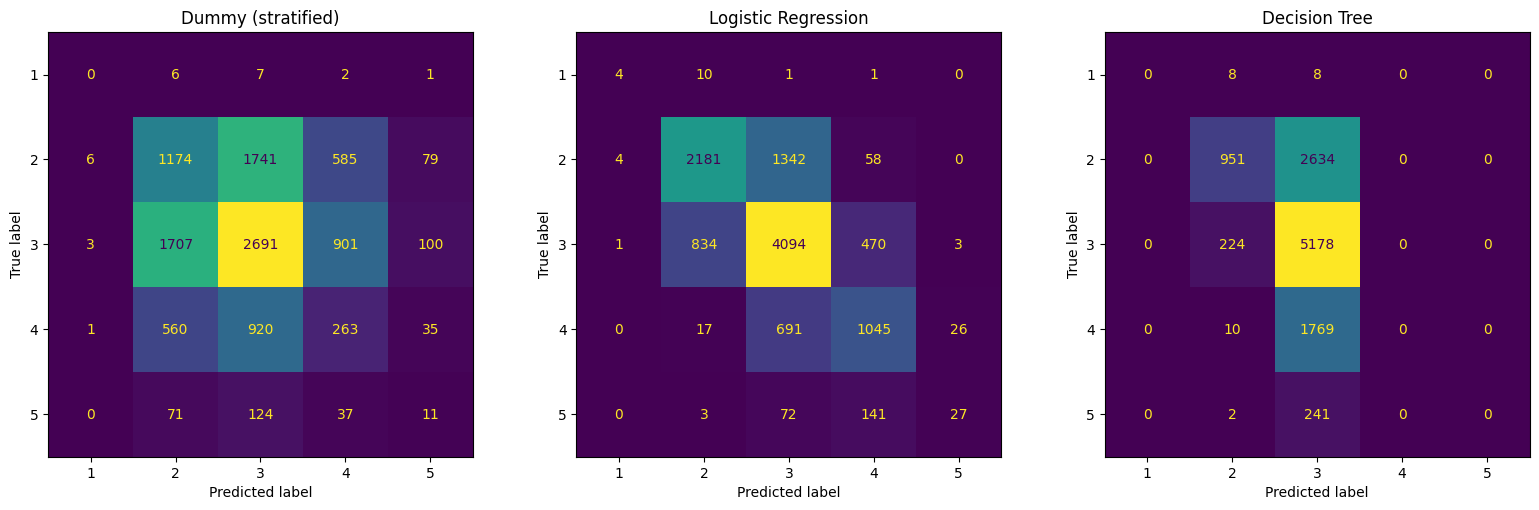

In [5]:
import os
os.makedirs("figs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name, preds in zip(
    axes, ["Dummy (stratified)", "Logistic Regression", "Decision Tree"],
    [pred_dummy, pred_logreg, pred_tree]):
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("figs/w6_confusion_all.png", dpi=120, bbox_inches="tight")
plt.show()

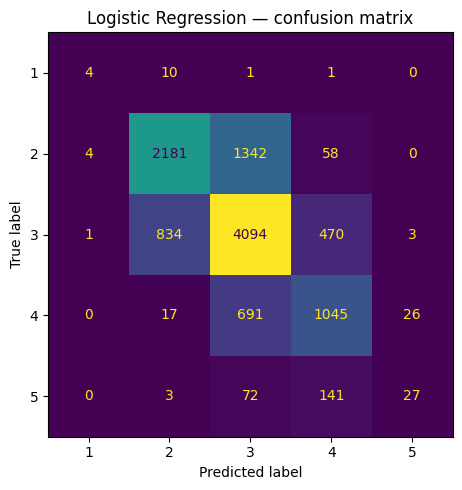

In [6]:
# Logistic regression confusion matrix saved standalone -- this is the one for the Discord post / report.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False)
ax.set_title("Logistic Regression — confusion matrix")
plt.tight_layout()
plt.savefig("figs/w6_confusion_logreg.png", dpi=120, bbox_inches="tight")
plt.show()

## 5 · Metric justification: why recall for ESI 1

Accuracy is dominated by ESI 3 (49% of all cases) and says nothing about the 0.1% of patients who are ESI 1 — the most urgent, resuscitate-now cases. A model can score well on accuracy while missing every single one of them. The clinical cost of the two error types is not symmetric: a **false negative on ESI 1** (calling a critical patient "not urgent") risks delayed resuscitation and death; a **false positive** (over-triaging a stable patient) costs staff time but is recoverable. That asymmetry is why **recall for ESI 1** — of the patients who are truly critical, what fraction did the model catch — is the primary metric here, ahead of accuracy, precision, or F1.

In [7]:
def summarise(name, preds):
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_test, preds), 3),
        "macro_precision": round(precision_score(y_test, preds, average="macro", zero_division=0), 3),
        "macro_recall": round(recall_score(y_test, preds, average="macro", zero_division=0), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "weighted_F1": round(f1_score(y_test, preds, average="weighted"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None, zero_division=0)[0], 3),
    }

table = pd.DataFrame([
    summarise("Dummy (stratified random guess)", pred_dummy),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree (max_depth=5)", pred_tree),
])
table

,model,accuracy,macro_precision,macro_recall,macro_F1,weighted_F1,recall_ESI1
0,Dummy (stratified random guess),0.375,0.204,0.204,0.204,0.375,0.00
1,Logistic Regression,0.667,0.582,0.463,0.492,0.661,0.25
2,Decision Tree (max_depth=5),0.556,0.265,0.245,0.216,0.463,0.00


In [8]:
print("=== Logistic Regression -- full classification report ===")
print(classification_report(y_test, pred_logreg, digits=3))

print("=== Decision Tree -- full classification report ===")
print(classification_report(y_test, pred_tree, digits=3))

print("=== Dummy baseline -- full classification report ===")
print(classification_report(y_test, pred_dummy, digits=3))

=== Logistic Regression -- full classification report ===
              precision    recall  f1-score   support

           1      0.444     0.250     0.320        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.587     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.582     0.463     0.492     11025
weighted avg      0.666     0.667     0.661     11025

=== Decision Tree -- full classification report ===
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.796     0.265     0.398      3585
           3      0.527     0.959     0.680      5402
           4      0.000     0.000     0.000      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.556     11025
   macro avg      0.2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 6 · Reading the results

- **Both real models beat the dummy baseline** on accuracy and macro-F1, so neither is worthless -- but "beats a coin flip" is a low bar with 5 classes.
- **Logistic regression is the stronger baseline overall** (accuracy 0.667 vs 0.556, macro-F1 0.492 vs 0.216) and is the only one of the two that catches *any* ESI 1 cases at all.
- **The decision tree, at `max_depth=5`, collapses toward the majority class.** It never predicts ESI 1, 4, or 5 on the test set -- recall and precision are 0 for all three. It over-fits to picking ESI 2/3 and looks reasonable on accuracy alone while being clinically unsafe for the rarer, more urgent levels. A deeper tree or class weighting would need to be tried before trusting a tree-based baseline.
- **Recall for ESI 1 is the number that matters most, and it is weak everywhere.** Logistic regression catches only 25% of true ESI 1 cases (4 of 16 in this test split); the tree catches 0%. In plain terms: **today's best baseline still misses about 3 in 4 of the most critical patients.** Neither model is close to safe for real triage support yet -- this is exactly the failure mode Week 7 tuning needs to target.
- ESI 1 is also extremely rare (77 of 55,121 encounters, 0.1%), so any single test split has only ~15-16 ESI 1 patients -- individual recall numbers here should be read as noisy, not precise.

## 7 · Save models and outputs

In [9]:
joblib.dump(logreg, "model_logreg.joblib")
joblib.dump(tree, "model_tree.joblib")
joblib.dump(scaler, "scaler.joblib")
table.to_csv("figs/w6_benchmark_table.csv", index=False)
print("Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib, figs/w6_benchmark_table.csv")

Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib, figs/w6_benchmark_table.csv
